In [1]:
import cfe

cfe.logger.setLevel("DEBUG")
cfe.settings.save_h5ad = True

INFO                                                                                                                                                                                                    
            _____     _ _ ______    _       ______            _                                                                                                                                         
           / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                                        
          | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                                                     
          | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                                                

In [2]:
fadata = cfe.data.read_pancrease()
fadata

DEBUG    |- Reading data from '/root/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad'...                                                                                                         
DEBUG    |- transfer 'X' and 'Spliced' matrix from csr to csc for better dynverse docker performance                                                                                                    
DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                                
DEBUG    |- recognizing prior information...                                                                                                                                                            
DEBUG    |--- recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                               

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cfe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

In [3]:
method = cfe.method.FateMethod(method_name="dynamo")
method.infer_trajectory(fadata)

DEBUG    |- load conda backend                                                                                                                                                                          
DEBUG    |--- Conda environment 'dynamo' is available: Python 3.10.18                                                                                                                                   
DEBUG    |- Loaded function 'dynamo': <function dynamo at 0x7e92294456c0>                                                                                                                               
INFO     |- method backend loaded: CondaBackend: dynamo in conda env 'dynamo'                                                                                                                           
DEBUG    |- set new log file: .cfe/pancreas/log/20251105_120424__dynamo-conda__FlFIzJwtMI.log                                                                                                       

  0%|          | 0/3696 [00:00<?, ?cells/s]

    finished (0:00:02) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 2 regions of root cells and 2 regions of end points .
    finished (0:00:11) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
running PAGA using priors: ['velocity_pseudotime']
    finished (0:00:00) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)
INFO     |- discrete milestones: ['Delta']                                                                                                                                                              
DEBUG    |- FateAnnData add_trajectory                                                                                                         

DEBUG    |- extract 'clusters' from prior infomation as parameter 'color'                                                                                                                               
DEBUG    |- extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                                                 
DEBUG    |- plot_trajectory                                                                                                                                                                             


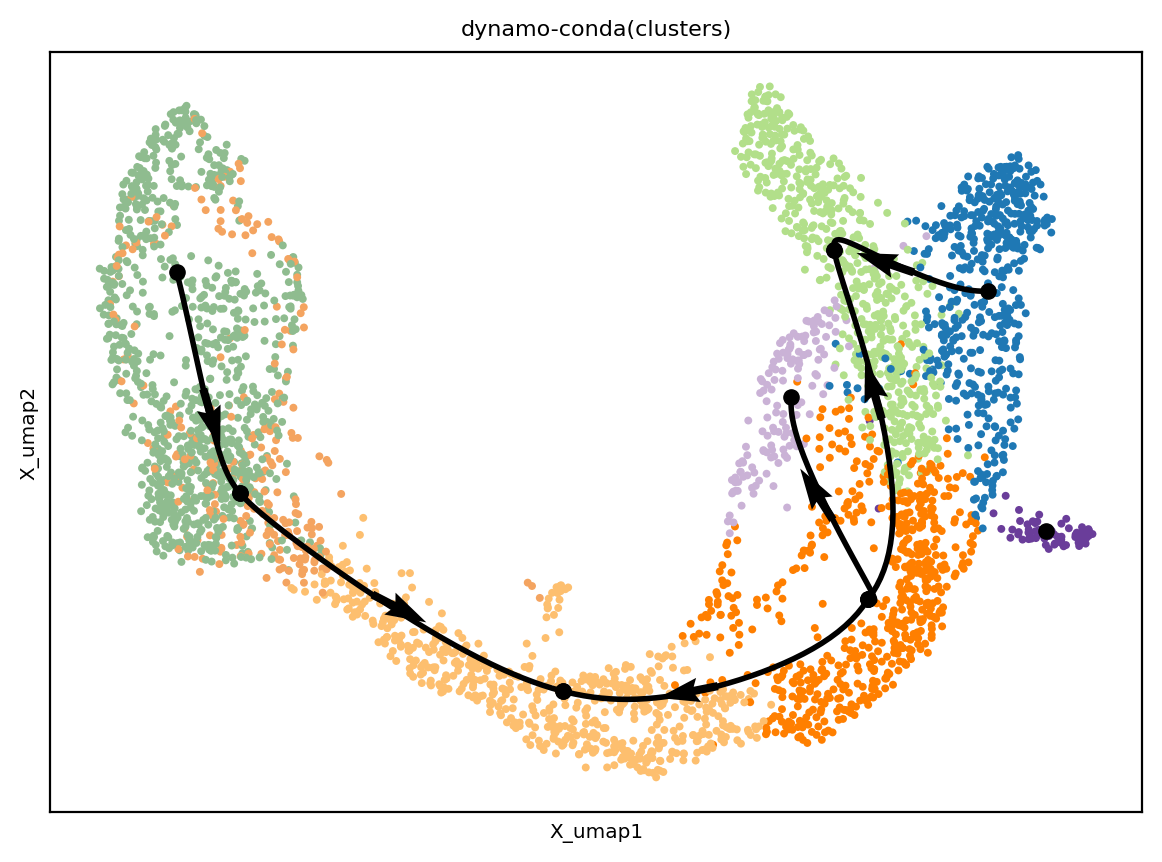

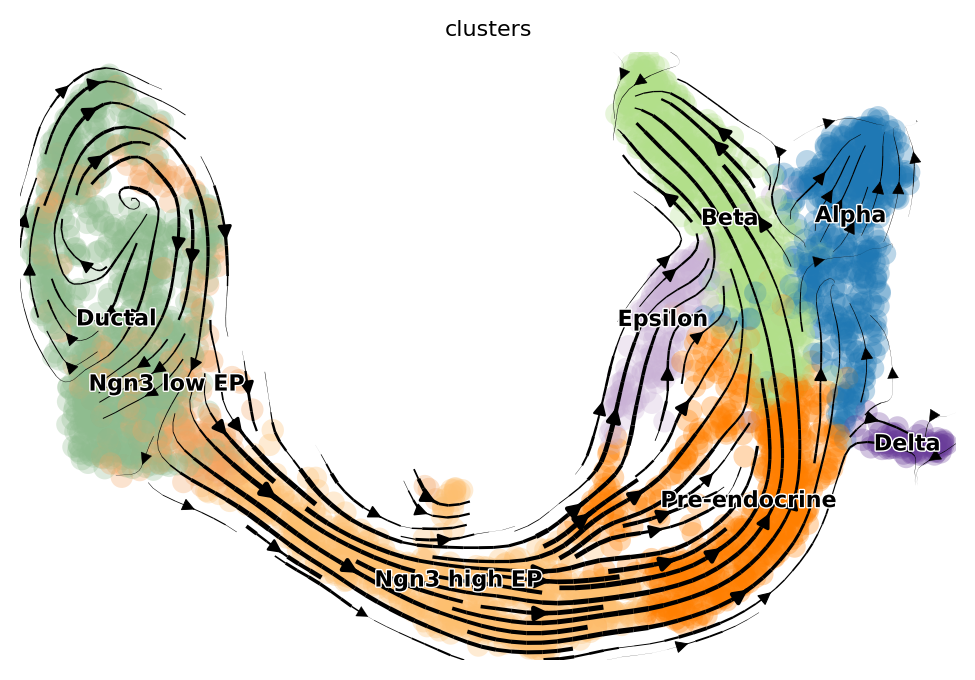

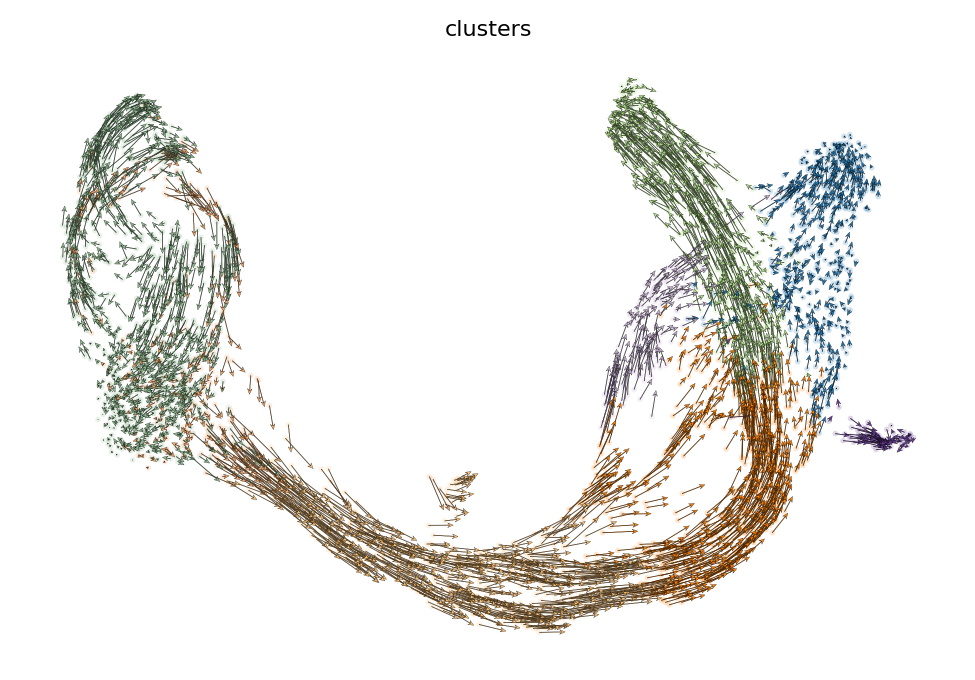

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cfe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

In [5]:
cfe.plot.plot_trajectory(fadata)
cfe.plot.plot_wrapper(fadata, wrapper_type="velocity")
cfe.plot.plot_wrapper(fadata, wrapper_type="velocity", mode="cell")
fadata

In [6]:
fadata.write_trajectory_dict()

DEBUG    |- write trajectory 'ref' to '.cfe/pancreas/trajectory_history/ref.pkl'                                                                                                                        
DEBUG    |- write trajectory '20251105_120424__dynamo-conda__FlFIzJwtMI' to '.cfe/pancreas/trajectory_history/20251105_120424__dynamo-conda__FlFIzJwtMI.pkl'                                            
